In [1]:
import pandas as pd
from pathlib import Path
from PIL import Image
from rembg import remove, new_session
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm
import matplotlib.pyplot as plt
import random
import numpy as np

C:\Users\LENOVO\DataspellProjects\Penyisihan_BDC_2026\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df_clean = pd.read_csv("dataset_cleaned.csv")
print(f"Jumlah gambar: {len(df_clean)}")

Jumlah gambar: 26197


## Padding ke data majalah

In [3]:
OUTPUT_DIR = Path('dataset_padding/Recyclable')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
BORDER_SIZE = 30

start_num, end_num = 7234, 8417
target_files = [f'R_{i}.jpg' for i in range(start_num, end_num + 1)]

mask_majalah = df_clean['file_path'].apply(lambda x: Path(x).name in target_files)
df_majalah = df_clean[mask_majalah]

print(f"Jumlah file yang akan diproses: {len(df_majalah)}")

processed = []
for idx, row in df_majalah.iterrows():
    src_path = Path(row['file_path'])
    if not src_path.exists():
        print(f"File tidak ditemukan: {src_path}")
        continue

    img = Image.open(src_path).convert('RGB')
    img_bordered = Image.new('RGB', img.size, color='white')
    img_bordered.paste(img, (0, 0))

    dst_path = OUTPUT_DIR / src_path.name
    img_bordered.save(dst_path)
    processed.append(src_path.name)

    df_clean.at[idx, 'final_path'] = str(dst_path)
    df_clean.at[idx, 'use_no_bg'] = False



Jumlah file yang akan diproses: 1183


In [4]:
print(f"Berhasil memproses {len(processed)} gambar.")

df_clean.to_csv('dataset_filtered_updated.csv', index=False)

Berhasil memproses 1183 gambar.
DataFrame diperbarui dan disimpan ke dataset_filtered_updated.csv


## Hapus Background

- Exclude Data Majalah: R_7234 sampai R_8417

In [5]:
OUTPUT_DIR = Path("dataset_no_bg")
OUTPUT_DIR.mkdir(exist_ok=True)

In [6]:
session = new_session(model_name='u2net', providers=['CUDAExecutionProvider'])

def remove_background_gpu(input_path, output_path):
    """
    Hapus background menggunakan rembg[gpu]

    :param input_path: path dari gambar yang menjadi input
    :param output_path: path dari gambar yang menjadi output
    :return:
    """
    try:
        with open(input_path, 'rb') as f:
            img_data = f.read()
        result = remove(img_data, session=session)
        with open(output_path, 'wb') as f:
            f.write(result)
        return True
    except Exception:
        Image.open(input_path).save(output_path)
        return False

In [7]:
target_files = [f'R_{i}.jpg' for i in range(7234, 8418)] # semua data majalah ada di id recyclable ini

mask_majalah = df_clean['file_path'].apply(lambda x: Path(x).name in target_files)

df_clean.loc[mask_majalah, 'use_no_bg'] = False
df_clean.loc[mask_majalah, 'final_path'] = df_clean.loc[mask_majalah, 'file_path']

paths_input = df_clean.loc[~mask_majalah, 'file_path'].tolist()

In [8]:
paths_output = []

for p in paths_input:
    rel = Path(p).relative_to("train")
    out = OUTPUT_DIR / rel
    out.parent.mkdir(parents=True, exist_ok=True)
    paths_output.append(str(out))

success_flags = []
with ThreadPoolExecutor(max_workers=1) as executor:
    futures = {
        executor.submit(remove_background_gpu, inp, out): i
        for i, (inp, out) in enumerate(zip(paths_input, paths_output))
    }
    for future in tqdm(as_completed(futures), total=len(futures)):
        success_flags.append(future.result())

100%|██████████| 25014/25014 [1:57:12<00:00,  3.56it/s]   


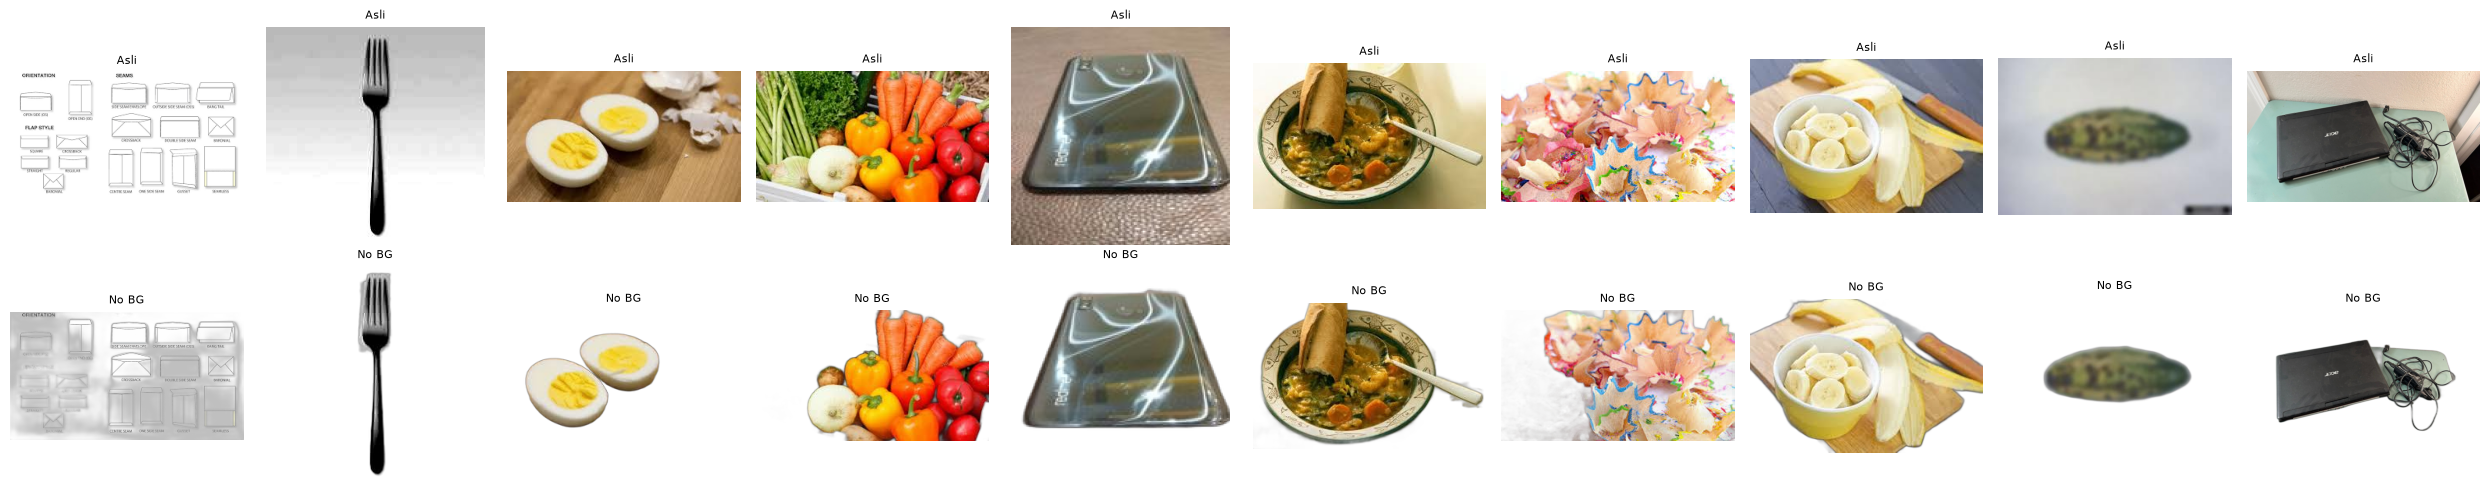

In [9]:
sample_indices = random.sample(range(len(paths_input)), min(10, len(paths_input)))

fig, axes = plt.subplots(2, len(sample_indices), figsize=(len(sample_indices) * 2.5, 5))

for i, idx in enumerate(sample_indices):
    img_original = Image.open(paths_input[idx])
    img_no_bg = Image.open(paths_output[idx])

    axes[0, i].imshow(img_original)
    axes[0, i].set_title("Asli", fontsize=8)
    axes[0, i].axis('off')

    axes[1, i].imshow(img_no_bg)
    axes[1, i].set_title("No BG", fontsize=8)
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

In [11]:
all_paths_output = [None] * len(df_clean)
all_success_flags = [False] * len(df_clean)

non_majalah_indices = df_clean[~mask_majalah].index.tolist()

for i, (pout, sflag) in enumerate(zip(paths_output, success_flags)):
    idx = non_majalah_indices[i]
    all_paths_output[idx] = pout
    all_success_flags[idx] = sflag

In [13]:
df_clean['file_path_no_bg'] = all_paths_output
df_clean['bg_removed_success'] = all_success_flags

df_clean.to_csv("dataset_preprocessed.csv", index=False)

### Validasi hapus BG

In [14]:
def peresentasi_foreground(img_path, threshold=30):
    """
    Hitung persentase piksel

    :param img_path: path dari gambar yang menjadi input
    """
    try:
        img = Image.open(img_path).convert('L')  # grayscale
        arr = np.array(img)
        foreground_pixels = np.sum(arr > threshold)
        total_pixels = arr.size
        return (foreground_pixels / total_pixels) * 100
    except Exception:
        return None

In [15]:
fg_percent = []
for path in tqdm(paths_output):
    pct = peresentasi_foreground(path)
    fg_percent.append(pct)

fg_percent = np.array(fg_percent)
valid_mask = fg_percent != None
fg_clean = fg_percent[valid_mask]

100%|██████████| 25014/25014 [02:23<00:00, 174.03it/s] 


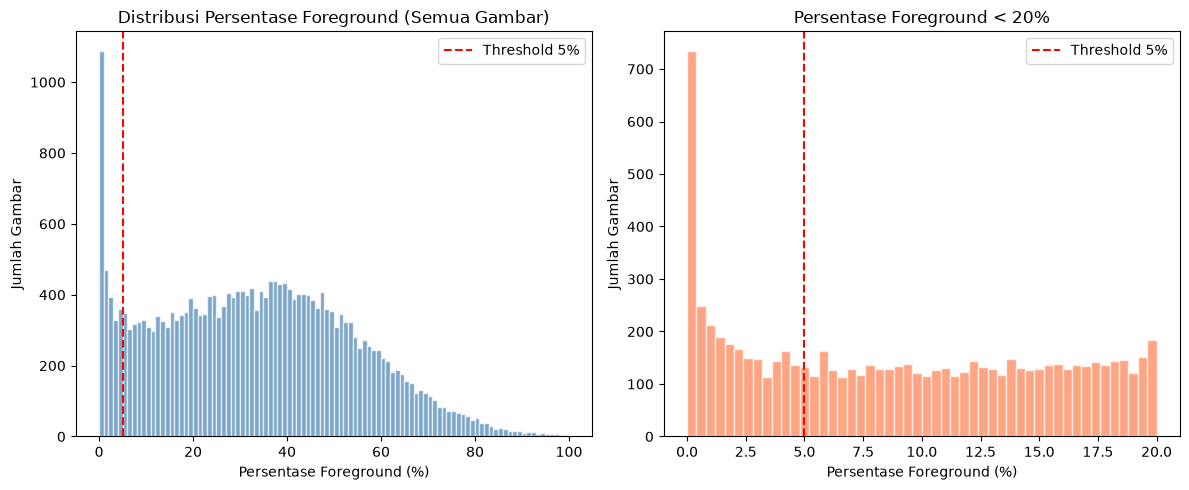

In [16]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(fg_clean, bins=100, color='steelblue', edgecolor='white', alpha=0.7)
plt.axvline(x=5, color='red', linestyle='--', label='Threshold 5%')
plt.xlabel('Persentase Foreground (%)')
plt.ylabel('Jumlah Gambar')
plt.title('Distribusi Persentase Foreground (Semua Gambar)')
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(fg_clean[fg_clean < 20], bins=50, color='coral', edgecolor='white', alpha=0.7)
plt.axvline(x=5, color='red', linestyle='--', label='Threshold 5%')
plt.xlabel('Persentase Foreground (%)')
plt.ylabel('Jumlah Gambar')
plt.title('Persentase Foreground < 20%')
plt.legend()

plt.tight_layout()
plt.show()


In [17]:
print(f"\nTotal gambar diproses: {len(fg_clean)}")
print(f"Mean foreground: {fg_clean.mean():.2f}%")
print(f"Median foreground: {np.median(fg_clean):.2f}%")
print(f"Gambar dengan FG < 1%: {np.sum(fg_clean < 1)}")
print(f"Gambar dengan FG < 5%: {np.sum(fg_clean < 5)}")
print(f"Gambar dengan FG < 10%: {np.sum(fg_clean < 10)}")


Total gambar diproses: 25014
Mean foreground: 33.20%
Median foreground: 32.75%
Gambar dengan FG < 1%: 1089
Gambar dengan FG < 5%: 2643
Gambar dengan FG < 10%: 4264


In [18]:
paths_no_bg_array = np.array(paths_output)
fg_array = np.array(fg_percent)
mask_1_to_2 =  (fg_array >= 1) & (fg_array < 10)
indices_1_to_2 = np.where(mask_1_to_2)[0]

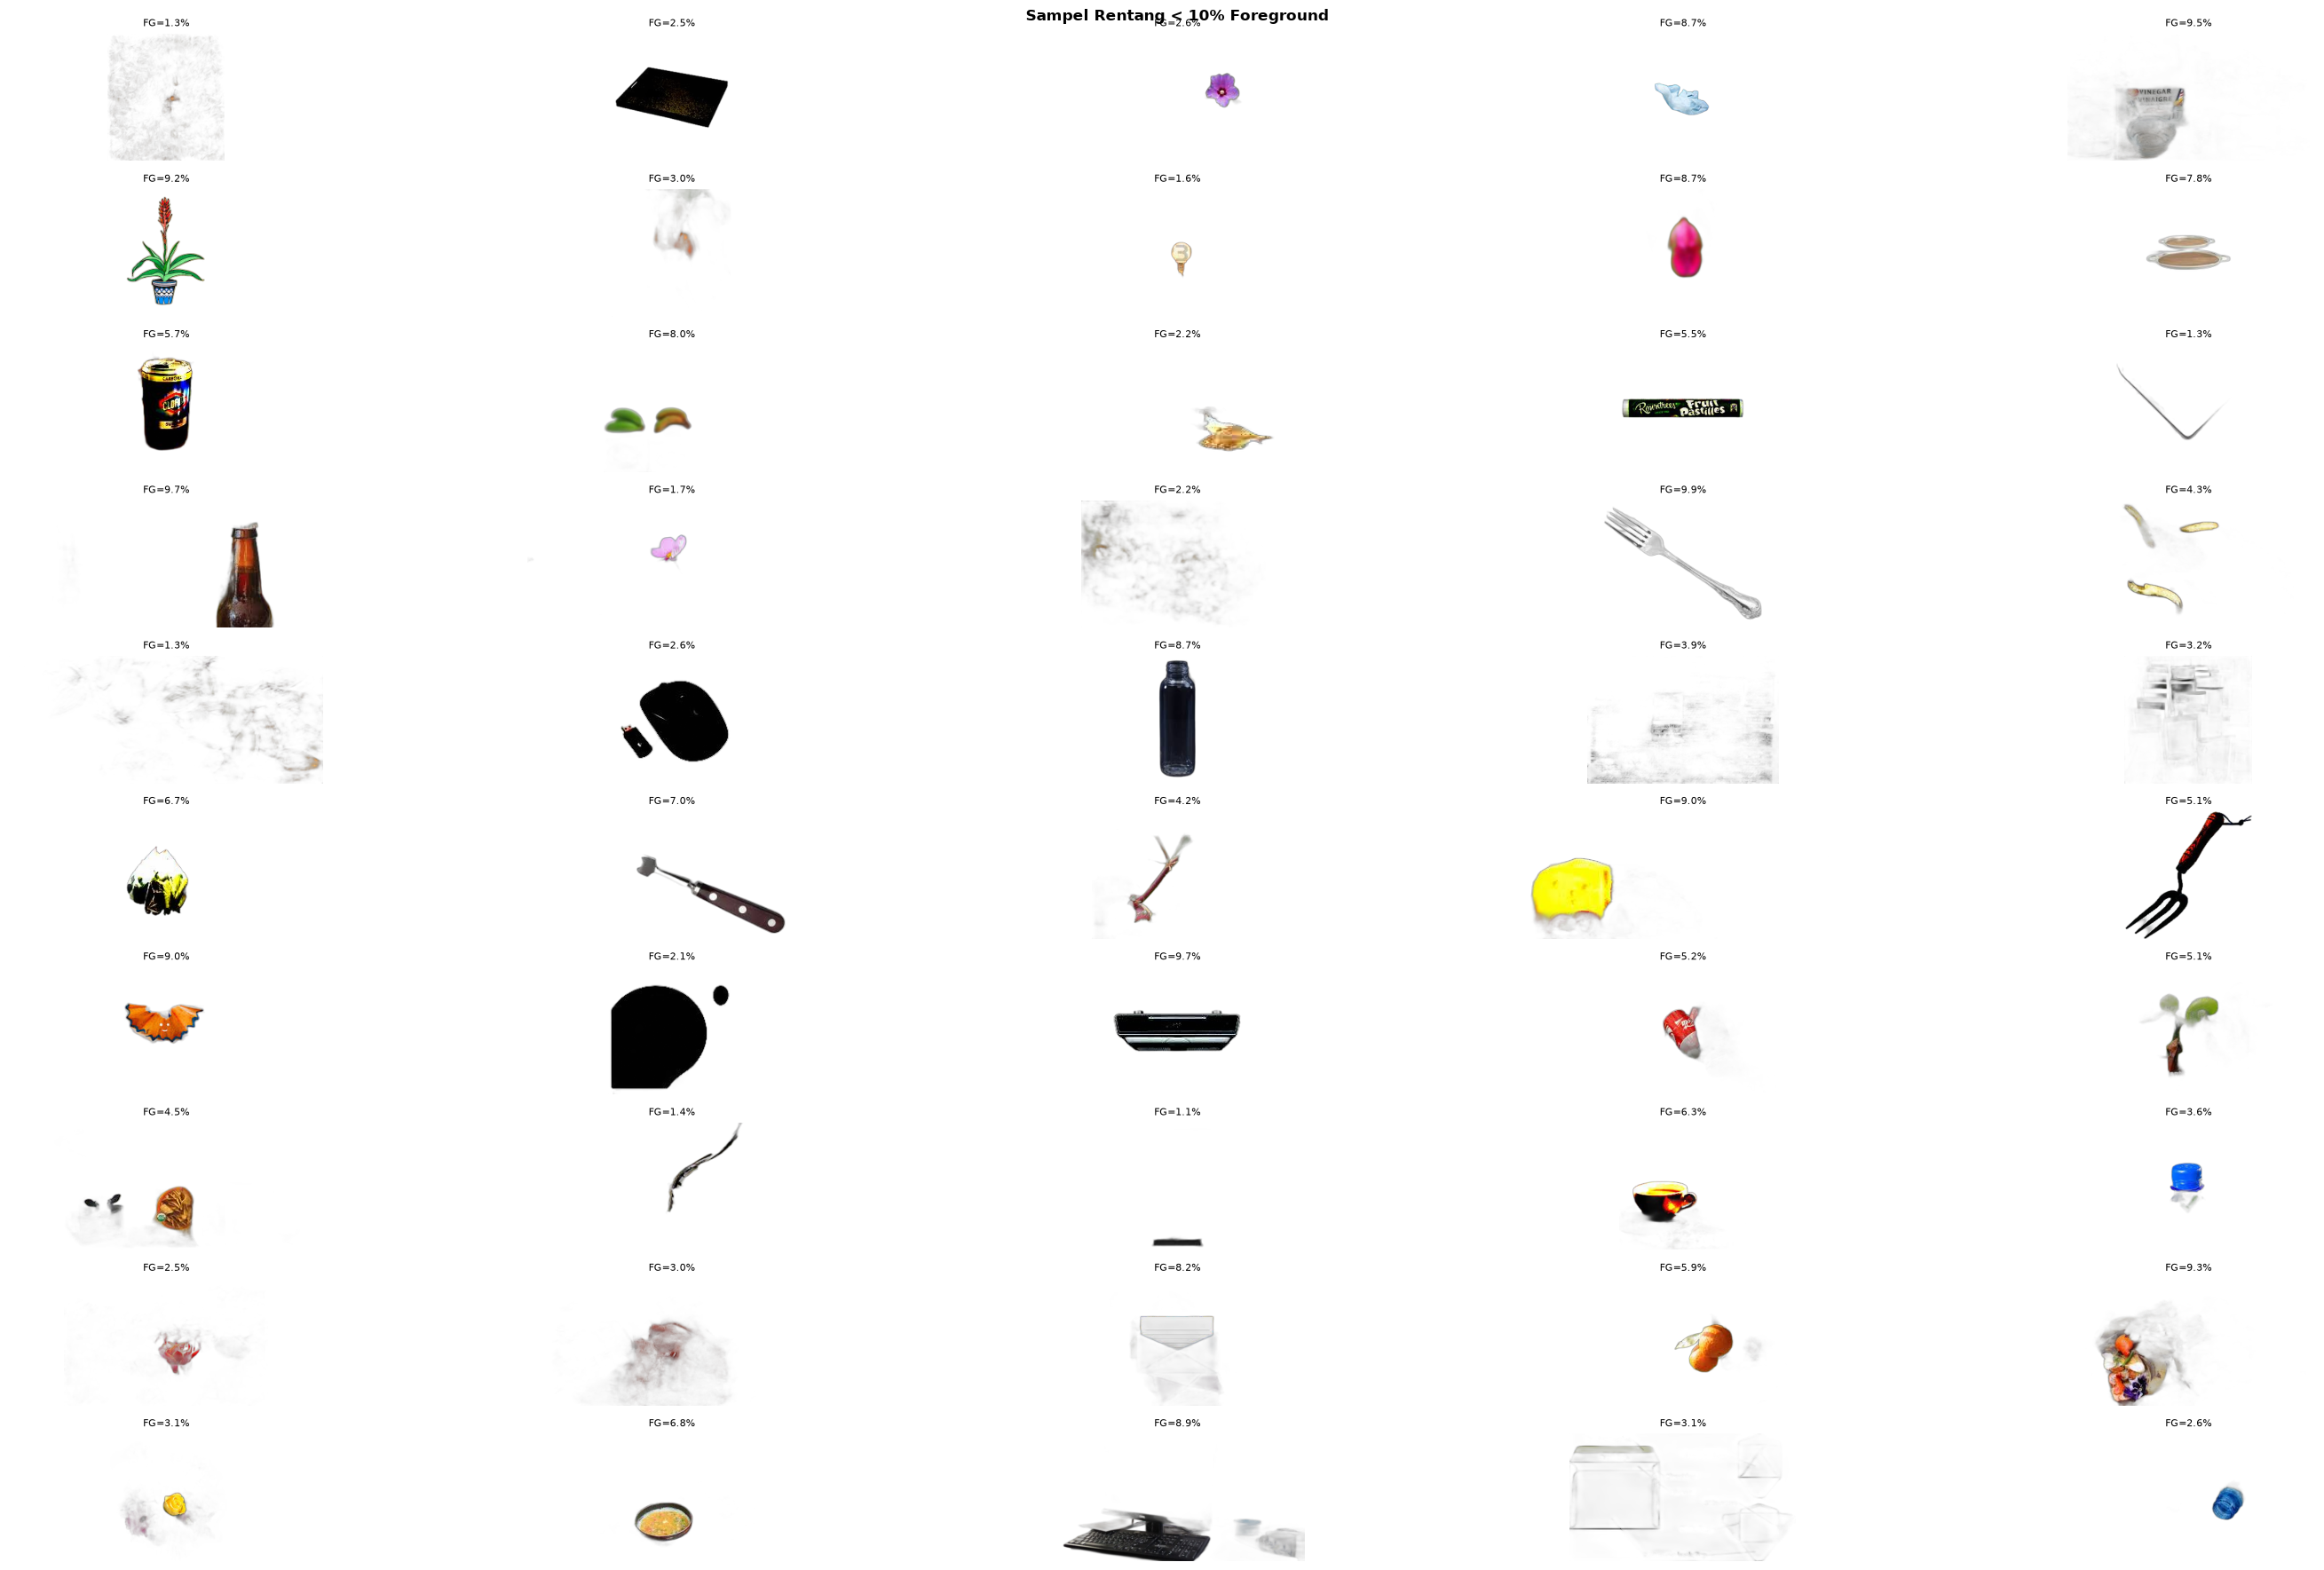

In [19]:
samples = random.sample(list(indices_1_to_2), min(50, len(indices_1_to_2)))
fig, axes = plt.subplots(10, 5, figsize=(30, 18))
axes = axes.flatten()
for i, idx in enumerate(samples):
    img = Image.open(paths_no_bg_array[idx])
    axes[i].imshow(img)
    axes[i].set_title(f"FG={fg_array[idx]:.1f}%", fontsize=8)
    axes[i].axis('off')
for j in range(len(samples), len(axes)):
    axes[j].axis('off')
plt.suptitle("Sampel Rentang < 10% Foreground", fontweight='bold')
plt.tight_layout()
plt.show()


> Beberapa contoh persentase foreground tinggi namun tidak menunjukkan objek yang dituju adalah majalah atau objek serupa yang memiliki wajah manusia di sampulnya

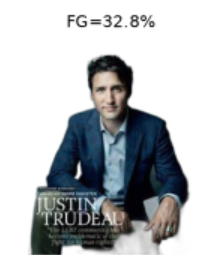

## Filter Dataset

In [24]:
import numpy as np
from pathlib import Path

THRESHOLD = 10.0

n_total = len(df_clean)
fg_array = np.full(n_total, np.nan)
paths_no_bg_array = np.full(n_total, None, dtype=object)
paths_asli_array = df_clean['file_path'].values.copy()

non_majalah_mask = ~df_clean['file_path'].apply(lambda x: Path(x).name in target_files)
non_majalah_indices = df_clean[non_majalah_mask].index

fg_array[non_majalah_indices] = fg_percent
paths_no_bg_array[non_majalah_indices] = paths_output

mask_success = fg_array >= THRESHOLD
mask_failed = fg_array < THRESHOLD

df_filtered = df_clean.copy()
df_filtered['fg_percentage'] = fg_array
df_filtered['use_no_bg'] = mask_success

df_filtered['final_path'] = np.where(
    mask_success,
    paths_no_bg_array,
    paths_asli_array
)

mask_recyclable = df_filtered['label'] == 'Recyclable'
df_filtered.loc[mask_recyclable, 'use_no_bg'] = False
df_filtered.loc[mask_recyclable, 'final_path'] = df_filtered.loc[mask_recyclable, 'file_path']

target_files = [f'R_{i}.jpg' for i in range(7234, 8418)]
mask_majalah = df_filtered['file_path'].apply(lambda x: Path(x).name in target_files)
padding_dir = Path('dataset_padding/Recyclable')
df_filtered.loc[mask_majalah, 'final_path'] = df_filtered.loc[mask_majalah, 'file_path'].apply(
    lambda p: str(padding_dir / Path(p).name)
)

df_filtered['fg_percentage'] = df_filtered['fg_percentage'].fillna(-1.0)

print(df_filtered['use_no_bg'].value_counts())
df_filtered.to_csv("dataset_filtered.csv", index=False)
print(f"Total gambar final: {len(df_filtered)}")

use_no_bg
True     13368
False    12829
Name: count, dtype: int64
Total gambar final: 26197


## Resize

In [25]:
df_filtered = pd.read_csv("dataset_filtered.csv")
TARGET_SIZE = 224
OUTPUT_DIR = Path("dataset_final")
OUTPUT_DIR.mkdir(exist_ok=True)

In [26]:
def letterbox_resize(img_path, target_size=TARGET_SIZE):
    """
    Resize gambar ke target_size x target_size dengan padding hitam
    untuk mempertahankan rasio aspek.

    :param img_path: path dari gambar yang akan diubah ukurannya
    :return canvas: gambar yang telah di resize
    """
    try:
        img = Image.open(img_path).convert('RGB')
        w, h = img.size
        # Hitung rasio resize
        ratio = min(target_size / w, target_size / h)
        new_w, new_h = int(w * ratio), int(h * ratio)
        img_resized = img.resize((new_w, new_h), Image.Resampling.LANCZOS)

        canvas = Image.new('RGB', (target_size, target_size), (0, 0, 0))
        offset_x = (target_size - new_w) // 2
        offset_y = (target_size - new_h) // 2
        canvas.paste(img_resized, (offset_x, offset_y))
        return canvas
    except Exception:
        return None

In [27]:
new_paths = []
for idx, row in tqdm(df_filtered.iterrows(), total=len(df_filtered)):
    src_path = row['final_path']
    label = row['label']

    fname = Path(row['file_path']).name
    dst_dir = OUTPUT_DIR / label
    dst_dir.mkdir(parents=True, exist_ok=True)
    dst_path = dst_dir / fname

    img_resized = letterbox_resize(src_path)
    if img_resized:
        img_resized.save(dst_path)
        new_paths.append(str(dst_path))
    else:
        new_paths.append(None)


print(f"Total gambar berhasil di-resize: {sum(1 for p in new_paths if p is not None)}")

100%|██████████| 26197/26197 [03:27<00:00, 126.13it/s] 

Total gambar berhasil di-resize: 26197


In [28]:
df_filtered['final_path_resized'] = new_paths
df_filtered.to_csv("dataset_final.csv", index=False)